## Browse-only rendering

This notebook is generated from `scripts/global_temperature_enso-prediction.py` purely for **browsing on GitHub** — code plus every figure, no clone or run required.

It is **not** part of the reproducibility contract. The authoritative source is the script under `scripts/`; regenerate the manuscript figures and tables with `make all`. Outputs here may carry machine-specific last-digit differences (the float32-SVD caveat documented in the README).

In [1]:
# browse-only shim (not in the committed scripts): render figures inline
%matplotlib inline
import matplotlib
matplotlib.use = lambda *a, **k: None  # neutralize the script's Agg switch


# ENSO-conditioned evolution of global mean surface temperature

Reproduction-capsule port of the analysis script that produces **9 figures and
4 tables** used by the manuscript. It is the oracle script
`scripts/global_temperature_enso-prediction.py` from the source project, trimmed
to the manuscript-mapped outputs (per `docs/phase0_dependency_trace.md`) and
retargeted to read only the frozen Zenodo v2 data in `data/`:

| Output | kind |
|---|---|
| `eofs_pcs.pdf`, `reconstruction_2pc.pdf`, `pc_correlations.pdf` | figure |
| `variance_explained_dc.pdf`, `simplified_pred.pdf`, `corr_dec_n34_by_month.pdf` | figure |
| `fit_idea2.pdf`, `fit_all.pdf`, `forecast.pdf` | figure |
| `regression_table_full.tex`, `regression_table_r1.tex` | table |
| `regression_table_dc2.tex`, `regression_table_dc2_roni.tex` | table |

Figures are written to `figures/`, tables to `tables/`. Exploratory diagnostics,
SST correlation maps (cartopy), the PMM/E-C sections, and the intermediate model
figures are cut; the few intermediates that live inside cut blocks but feed kept
outputs (`time_fit`, `beta_dec_n34`, `pc_level`, the ENSO-response betas,
`gmt_fit_2c`, the shared y-limit block) are retained.

In [2]:
import os
import string
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
import matplotlib
matplotlib.use('Agg')
from matplotlib import pyplot as plt

# ── Paths ──────────────────────────────────────────────────────────────────
# _ROOT is the capsule root (holds data/, scripts/, figures/, tables/). As a
# script __file__ gives it directly; executed as a notebook (jupytext --execute)
# __file__ is undefined, so fall back to the nearest ancestor of the CWD that
# contains data/.
try:
    _ROOT = Path(__file__).resolve().parent.parent
except NameError:
    _ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / 'data').is_dir()), Path.cwd())
DATA_DIR    = _ROOT / 'data'
# Output dirs default to the capsule's figures/ and tables/. `make verify`
# overrides them (CAPSULE_FIGURES_DIR / CAPSULE_TABLES_DIR) to build into a
# scratch tree and diff against the committed reference copies.
FIGURES_DIR = Path(os.environ.get('CAPSULE_FIGURES_DIR', _ROOT / 'figures'))
TABLES_DIR  = Path(os.environ.get('CAPSULE_TABLES_DIR',  _ROOT / 'tables'))
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# ── Layout option ──────────────────────────────────────────────────────────
# FOUR_FIG = True: panel letters are continuous within each composite figure and
# reset to (a) at the start of each of the 4 composite figures.
# Fig 1: eofs_pcs(4) + reconstruction_2pc(2)       → a–f
# Fig 2: pc_correlations(2) + fit_reduction1(1)     → a–c
# Fig 3: eofs_pcs_dc(2) + fit_idea2(1)              → a–c
# Fig 4: hindcast_panels(6) + forecast(2)            → a–h
# variance_explained_dc is not in the four-fig layout; labeled (a)(b) as usual.
FOUR_FIG = True

_FOUR_FIG_START = {
    'eofs_pcs':              0,   # a–d  (Fig 1)
    'reconstruction_2pc':    4,   # e–f  (Fig 1)
    'pc_correlations':       0,   # a–b  (Fig 2, resets)
    'fit_reduction1':        2,   # c    (Fig 2)
    'variance_explained_dc': 0,   # not in four-fig layout; label (a)(b) normally
    'eofs_pcs_dc':           0,   # a–b  (Fig 3, resets)
    'fit_idea2':             2,   # c    (Fig 3)
    'fit_all':               2,   # c    (standalone)
    'hindcast_panels':       0,   # a–f  (Fig 4, resets)
    'forecast':              3,   # d    (Fig 4)
    'simplified_pred':       0,   # standalone
}

# ── Plot helpers ───────────────────────────────────────────────────────────
prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]
fig_letters = [f"({a}) " for a in string.ascii_lowercase]

def label_panels(axes, start=0):
    """Prepend '(a) ', '(b) ', … to existing ax.set_title text."""
    for i, ax in enumerate(axes):
        letter = chr(ord('a') + start + i)
        ax.set_title(f'({letter}) {ax.get_title()}')

def label_fig(axes_flat, name):
    """Label panels (a)(b)….
    FOUR_FIG=False: each figure starts at (a); names not in _FOUR_FIG_START are skipped.
    FOUR_FIG=True:  use offset from _FOUR_FIG_START so letters continue within
                    each composite figure and reset at the composite figure boundary.
    """
    if FOUR_FIG:
        label_panels(axes_flat, start=_FOUR_FIG_START[name])
    elif name not in ('fit_reduction1', 'fit_idea2', 'fit_all', 'forecast'):
        label_panels(axes_flat, start=0)
month_str = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
m_str = [s[0] for s in month_str]
# Month labels in June–May order (column order of the June-May matrix)
m_str_jm = month_str[5:] + month_str[:5]   # ['Jun','Jul',…,'May']

# ── Analysis period ────────────────────────────────────────────────────────
PERIOD   = slice("1979-01-01", "2026-12-01")
year_str = PERIOD.start[:4] + "–" + PERIOD.stop[:4]

## Data

The frozen archive file `obs_n34_GMSTa_185001-202605.nc` supplies both series
used here: observed Niño-3.4 SST (absolute, from Jan 1979) and the NOAA
GlobalTemp global-mean anomaly `GMSTa` (full record from Jan 1850). The
preindustrial shift `GMT_PREIND_SHIFT` is `-mean(GMSTa, 1850–1900)`, computed
exactly as in the original from the full record; it is added to anomalies to
express them as °C above 1850–1900. (The archive `GMSTa` reference period is
1991–2020 rather than the original NOAA base; because the final trajectories
subtract the 1850–1900 mean, that constant offset cancels — the plotted values
are invariant to the base period.)

In [3]:
ds_obs = xr.open_dataset(DATA_DIR / 'obs_n34_GMSTa_185001-202605.nc').load()

# ── Nino-3.4 (ERSSTv5 area mean, absolute SST, provided from Jan 1979) ──────
n34 = ds_obs.n34.sel(time=PERIOD)          # slice drops the NaN pre-1979 rows
print(f"n34:  {dict(n34.sizes)}  units: {n34.attrs.get('units','?')}")

# ── GMT (NOAA GlobalTemp anomaly, full record from Jan 1850) ────────────────
gmt_all = ds_obs.GMSTa
# Amount to ADD to the anomalies to express in °C above 1850–1900.
# The 1850–1900 mean of the anomaly field is negative (preindustrial was colder
# than the base period), so subtracting it = adding a positive number.
GMT_PREIND_SHIFT = -float(gmt_all.sel(time=slice('1850', '1900')).mean())
print(f"Preindustrial shift (subtract 1850–1900 mean): +{GMT_PREIND_SHIFT:.4f} degC")
gmt = gmt_all.sel(time=PERIOD)
print(f"gmt:  {dict(gmt.sizes)}  units: {gmt.attrs.get('units','?')}")

# ── Anomalies: remove monthly climatology ─────────────────────────────────
# n34 is raw SST → subtract monthly mean to get anomaly
# gmt is already an anomaly field → remove residual seasonal cycle
n34a = n34.groupby('time.month') - n34.groupby('time.month').mean('time')
gmta = gmt.groupby('time.month') - gmt.groupby('time.month').mean('time')
n34a.attrs.update({'units': 'degC', 'long_name': 'Nino-3.4'})
gmta.attrs.update({'units': 'degC', 'long_name': 'GMT anomaly'})

n34:  {'time': 569}  units: degC
Preindustrial shift (subtract 1850–1900 mean): +0.7840 degC
gmt:  {'time': 569}  units: degC


## June–May matrices and annual-cycle removal

Reshape each monthly series into a `(N_years, 12)` matrix whose columns run
June→May, then subtract column means so each calendar month averages to zero
across years. The stored `gmt_col_mean` (seasonal cycle in anomaly space) and
the 1991–2020 Niño-3.4 climatology shift are needed to rebuild trajectories for
plotting.

In [4]:
# =============================================================================
# June–May matrices
# Shape: (N_years, 12), C order → .flatten() returns the original time series.
# Column 0 = June, column 11 = May.
# 47 full years: 1979-Jun to 2026-May.
# =============================================================================
N_years = 47
JM_SLICE = slice('1979-06-01', '2026-05-01')

n34_june_may = n34a.sel(time=JM_SLICE).values.reshape(N_years, 12)
gmt_june_may = gmta.sel(time=JM_SLICE).values.reshape(N_years, 12)

years = np.arange(1979, 1979 + N_years)          # start year of each Jun–May segment
time_monthly = pd.date_range('1979-06', periods=N_years * 12, freq='MS')

print(f"June–May matrix shapes: n34={n34_june_may.shape}, gmt={gmt_june_may.shape}")

# ── Annual-cycle removal (subtract column means) ───────────────────────────
# After this step each column (= calendar month) averages to zero across years.
# Use nanmean so any missing values in ERSSTv5 don't corrupt the centering.
# gmt_col_mean is stored: needed to reconstruct full trajectories for plotting
# and for converting back to preindustrial units (add gmt_col_mean + GMT_PREIND_SHIFT).
col_mean_n34 = np.nanmean(n34_june_may, axis=0)
A_n34 = n34_june_may - col_mean_n34
gmt_col_mean = np.nanmean(gmt_june_may, axis=0)   # (12,)  seasonal cycle in anomaly space
A_gmt = gmt_june_may - gmt_col_mean

# N34 1991–2020 climatology shift: add to full-period anomaly → 1991–2020 anomaly.
# full_period_anom = raw − full_clim; 1991_2020_anom = raw − 1991_2020_clim
# → 1991_2020_anom = full_period_anom + (full_clim − 1991_2020_clim)
_n34_full_clim_da    = n34.groupby('time.month').mean('time')               # month=1..12
_n34_1991_2020_clim_da = (n34.sel(time=slice('1991-01', '2020-12'))
                              .groupby('time.month').mean('time'))
N34_SHIFT_1991_2020  = _n34_full_clim_da - _n34_1991_2020_clim_da          # DataArray, month=1..12
# Jun–May column order: Jun=5,Jul=6,...,Dec=11,Jan=0,...,May=4  (1-indexed calendar months)
N34_JM_SHIFT = N34_SHIFT_1991_2020.values[[5, 6, 7, 8, 9, 10, 11, 0, 1, 2, 3, 4]]  # (12,)
N34_DEC_1991_2020_SHIFT = float(N34_SHIFT_1991_2020.sel(month=12))         # December scalar
print(f"N34 Dec 1991–2020 shift: {N34_DEC_1991_2020_SHIFT:+.4f} °C"
      f"  (add to full-period anomaly to get 1991–2020 anomaly)")

for name, A in [('n34', A_n34), ('gmt', A_gmt)]:
    n_nan = np.isnan(A).sum()
    if n_nan > 0:
        print(f"Warning: {n_nan} NaN values in {name} June–May matrix")

June–May matrix shapes: n34=(47, 12), gmt=(47, 12)
N34 Dec 1991–2020 shift: -0.0230 °C  (add to full-period anomaly to get 1991–2020 anomaly)


## PCA via SVD

Decompose each column-centered June–May matrix with the convention
`Data = EOFs @ PCs`: EOFs carry physical units (°C per unit PC), PCs have unit
variance. Signs are fixed so each EOF is positive in February.

In [5]:
# =============================================================================
# PCA via SVD
# Convention: Data = EOFs @ PCs
#   A       shape (N_years, 12)  — centered June–May matrix
#   A.T     shape (12, N_years)  — what we decompose
#   EOFs    shape (12, k)        — physical units (degC per unit PC)
#   PCs     shape (k, N_years)   — unit variance
#   Reconstruction: A.T ≈ EOFs @ PCs → A ≈ (EOFs @ PCs).T
# =============================================================================
def svd_pca(A):
    """PCA via SVD. A: (n_years, 12), column-centered.
    Returns EOF (12, k), PC (k, n_years), s (k,).
    PCs have unit variance; EOFs carry physical units."""
    N = A.shape[0]
    U, s, Vt = np.linalg.svd(A.T, full_matrices=False)  # A.T is (12, N_years)
    EOF = U * s / np.sqrt(N - 1)      # (12, k)  physical units
    PC  = Vt * np.sqrt(N - 1)         # (k, N_years)  unit variance
    return EOF, PC, s


EOF_n34, PC_n34, s_n34 = svd_pca(A_n34)
EOF_gmt, PC_gmt, s_gmt = svd_pca(A_gmt)

# ── Verify unit variance ───────────────────────────────────────────────────
assert np.allclose(PC_n34.var(axis=1, ddof=1), 1, atol=1e-10), "PC_n34 not unit variance"
assert np.allclose(PC_gmt.var(axis=1, ddof=1), 1, atol=1e-10), "PC_gmt not unit variance"

# ── Sign convention: EOF positive in February (index 8 in Jun–May order) ──
# June=0, Jul=1, ..., Dec=6, Jan=7, Feb=8, Mar=9, Apr=10, May=11
for ii in range(12):
    if EOF_n34[8, ii] < 0:
        EOF_n34[:, ii] *= -1
        PC_n34[ii, :]  *= -1
    if EOF_gmt[8, ii] < 0:
        EOF_gmt[:, ii] *= -1
        PC_gmt[ii, :]  *= -1

# ── Variance explained ────────────────────────────────────────────────────
var_n34 = s_n34**2 / np.sum(s_n34**2) * 100   # % per mode
var_gmt = s_gmt**2 / np.sum(s_gmt**2) * 100

print(f"\nVariance explained (N34): "
      f"PC1={var_n34[0]:.1f}%  PC2={var_n34[1]:.1f}%  "
      f"cumulative 2: {var_n34[:2].sum():.1f}%")
print(f"Variance explained (GMT): "
      f"PC1={var_gmt[0]:.1f}%  PC2={var_gmt[1]:.1f}%  "
      f"cumulative 2: {var_gmt[:2].sum():.1f}%")


Variance explained (N34): PC1=88.8%  PC2=6.0%  cumulative 2: 94.8%
Variance explained (GMT): PC1=92.0%  PC2=3.1%  cumulative 2: 95.1%


## Figure — `eofs_pcs.pdf`: EOFs and PCs (first two modes)

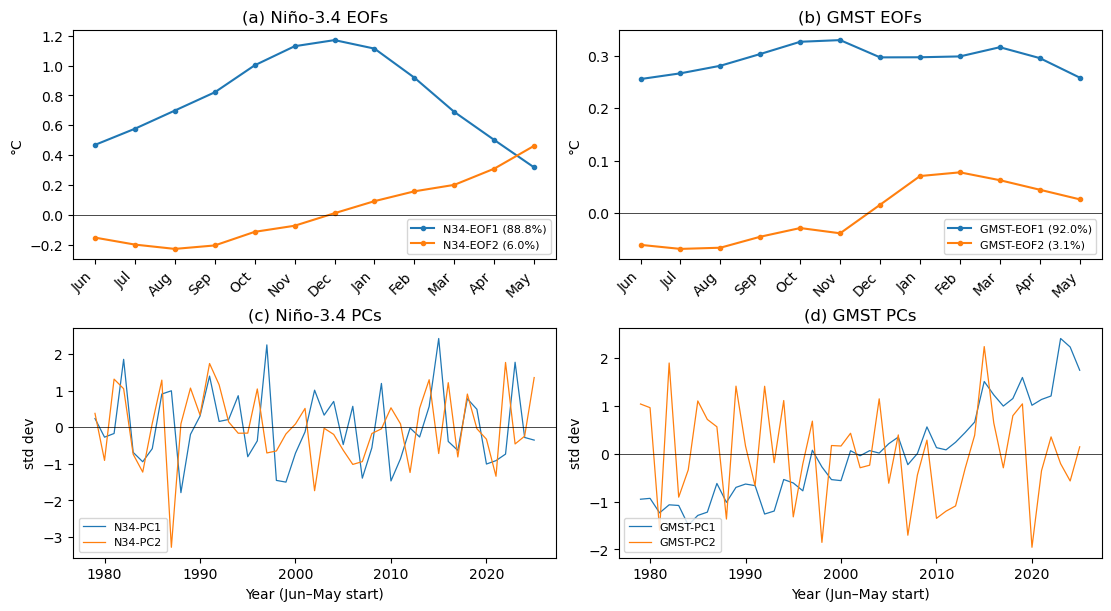

In [6]:
x_eof = np.arange(12)

fig, axs = plt.subplots(2, 2, figsize=(11, 6), layout='constrained')

for col, (EOF, PC, var, label, prefix) in enumerate([
        (EOF_n34, PC_n34, var_n34, 'Niño-3.4', 'N34'),
        (EOF_gmt, PC_gmt, var_gmt, 'GMST', 'GMST')]):
    # ── EOFs ──
    ax = axs[0, col]
    for k, c in enumerate(colors[:2]):
        ax.plot(x_eof, EOF[:, k], color=c, label=f'{prefix}-EOF{k+1} ({var[k]:.1f}%)', marker='o', ms=3)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xticks(x_eof)
    ax.set_xticklabels(m_str_jm, rotation=45, ha='right')
    ax.set_ylabel('°C')
    ax.set_title(f'{label} EOFs')
    ax.legend(fontsize=8, loc='lower right')

    # ── PCs ──
    ax = axs[1, col]
    for k, c in enumerate(colors[:2]):
        ax.plot(years, PC[k], color=c, label=f'{prefix}-PC{k+1}', lw=0.9)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Year (Jun–May start)')
    ax.set_ylabel('std dev')
    ax.set_title(f'{label} PCs')
    ax.legend(fontsize=8, loc='lower left' if col == 1 else 'best')

label_fig(axs.flatten(), 'eofs_pcs')
fig.savefig(FIGURES_DIR / 'eofs_pcs.pdf', bbox_inches='tight', metadata={'CreationDate': None})
plt.show()

## Figure — `reconstruction_2pc.pdf`: 2-PC reconstruction vs original

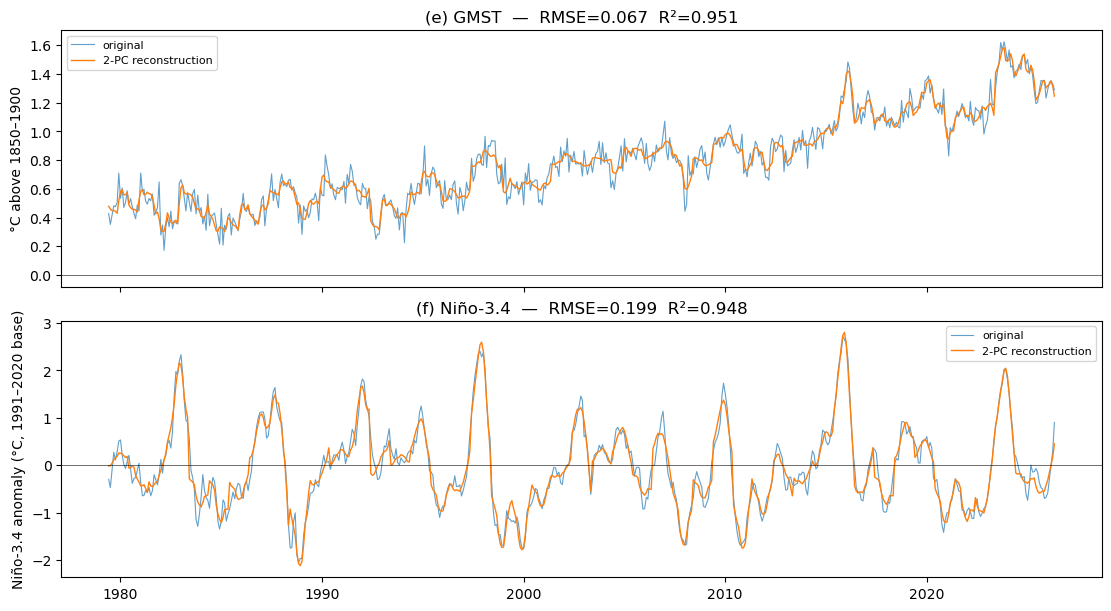

In [7]:
recon_n34 = (EOF_n34[:, :2] @ PC_n34[:2]).T.flatten()   # (N_years*12,) in A_n34 space
recon_gmt = (EOF_gmt[:, :2] @ PC_gmt[:2]).T.flatten()

orig_n34 = A_n34.flatten()    # full-period anomaly space (used for RMSE/R² in title)
orig_gmt = A_gmt.flatten()

# N34 in 1991–2020 anomaly space for plotting (add col_mean_n34 + 1991–2020 shift)
orig_n34_plot  = (n34_june_may + N34_JM_SHIFT[np.newaxis, :]).flatten()
recon_n34_plot = recon_n34 + np.tile(col_mean_n34 + N34_JM_SHIFT, N_years)

def rmse_r2(truth, pred):
    rmse = np.sqrt(np.mean((truth - pred)**2))
    r2   = 1 - np.sum((truth - pred)**2) / np.sum((truth - truth.mean())**2)
    return rmse, r2

rmse_n34, r2_n34 = rmse_r2(orig_n34, recon_n34)
rmse_gmt, r2_r2_gmt = rmse_r2(orig_gmt, recon_gmt)

# Convert GMT to preindustrial units for plotting:
# A_gmt = gmt_june_may - gmt_col_mean, so add both back plus the baseline offset.
gmt_col_mean_tiled = np.tile(gmt_col_mean, N_years)
orig_gmt_preind  = orig_gmt  + gmt_col_mean_tiled + GMT_PREIND_SHIFT
recon_gmt_preind = recon_gmt + gmt_col_mean_tiled + GMT_PREIND_SHIFT

fig, axs = plt.subplots(2, 1, figsize=(11, 6), layout='constrained', sharex=True)
for ax, orig_plot, recon_plot, orig_anom, recon_anom, label, ylabel in [
        (axs[0], orig_gmt_preind,  recon_gmt_preind, orig_gmt,  recon_gmt,
         'GMST', '°C above 1850–1900'),
        (axs[1], orig_n34_plot,    recon_n34_plot,   orig_n34,  recon_n34,
         'Niño-3.4', 'Niño-3.4 anomaly (°C, 1991–2020 base)')]:
    rmse, r2 = rmse_r2(orig_anom, recon_anom)
    ax.plot(time_monthly, orig_plot,  lw=0.8, alpha=0.7, label='original')
    ax.plot(time_monthly, recon_plot, lw=1.0,             label='2-PC reconstruction')
    ax.axhline(0, color='k', lw=0.4)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{label}  —  RMSE={rmse:.3f}  R²={r2:.3f}')
    ax.legend(fontsize=8)

label_fig(axs, 'reconstruction_2pc')
fig.savefig(FIGURES_DIR / 'reconstruction_2pc.pdf', bbox_inches='tight', metadata={'CreationDate': None})
plt.show()

## Figure — `pc_correlations.pdf`: simultaneous and lag-1 PC cross-correlations


Simultaneous cross-correlation matrix:
             GMST-PC1   GMST-PC2    N34-PC1    N34-PC2
  GMST-PC1      1.000     -0.000      0.158     -0.029
  GMST-PC2     -0.000      1.000      0.610      0.160
   N34-PC1      0.158      0.610      1.000      0.000
   N34-PC2     -0.029      0.160      0.000      1.000
GMT PC1 lag-1 autocorrelation: 0.920
GMT PC2 lag-1 autocorrelation: -0.182


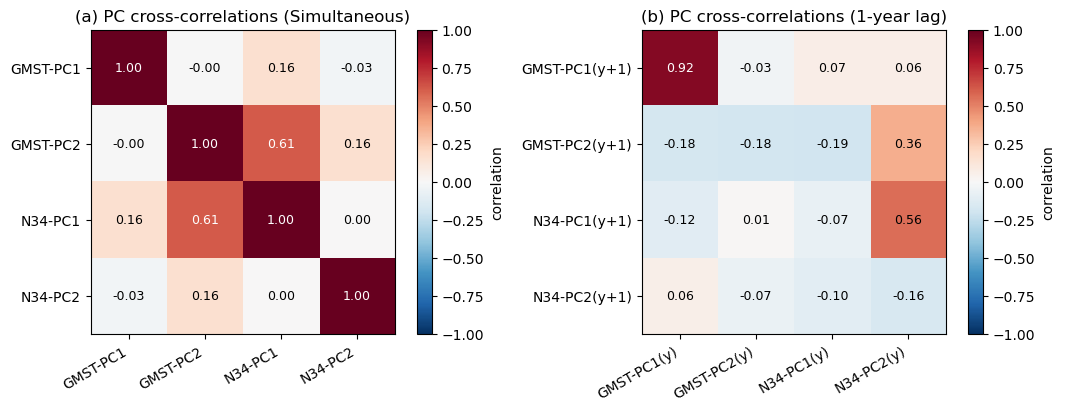

In [8]:
# =============================================================================
# Correlation diagnostics
# =============================================================================
labels_pc = ['GMST-PC1', 'GMST-PC2', 'N34-PC1', 'N34-PC2']
C = np.corrcoef(np.vstack([PC_gmt[:2], PC_n34[:2]]))

print("\nSimultaneous cross-correlation matrix:")
header = f"{'':>10}" + "".join(f"  {lb:>9}" for lb in labels_pc)
print(header)
for i, row in enumerate(C):
    print(f"{labels_pc[i]:>10}" + "".join(f"  {v:>9.3f}" for v in row))

# Lag-1 autocorrelation of GMT PCs (1-year lag — each sample = one Jun–May year)
for k in range(2):
    r = np.corrcoef(PC_gmt[k, :-1], PC_gmt[k, 1:])[0, 1]
    print(f"GMT PC{k+1} lag-1 autocorrelation: {r:.3f}")

# ── simultaneous + lag-1 cross-correlation heatmaps (1×2) ────────────────
# Lag-1: rows = t+1 (predictands), columns = t (predictors)
C_lag1 = np.corrcoef(
    np.vstack([PC_gmt[:2, :-1], PC_n34[:2, :-1]]),   # (4, N-1)  at t
    np.vstack([PC_gmt[:2, 1:],  PC_n34[:2, 1:]])      # (4, N-1)  at t+1
)[:4, 4:].T   # transpose: rows = t+1, columns = t

labels_t  = [f'{lb}(y)'   for lb in labels_pc]
labels_t1 = [f'{lb}(y+1)' for lb in labels_pc]

fig, axs = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')

for ax, mat, xlabels, ylabels, title in [
        (axs[0], C,      labels_pc, labels_pc, 'Simultaneous'),
        (axs[1], C_lag1, labels_t,  labels_t1, '1-year lag')]:
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(4)); ax.set_xticklabels(xlabels, rotation=30, ha='right')
    ax.set_yticks(range(4)); ax.set_yticklabels(ylabels)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=9, color='k' if abs(mat[i,j]) < 0.6 else 'w')
    fig.colorbar(im, ax=ax, label='correlation')
    ax.set_title(f'PC cross-correlations ({title})')

label_fig(axs, 'pc_correlations')
fig.savefig(FIGURES_DIR / 'pc_correlations.pdf', bbox_inches='tight', metadata={'CreationDate': None})
plt.show()

## Full conditional regression (4-PC benchmark)

Predict GMST PC1/PC2 at year *t+1* from GMST PC1/PC2 at *t* and Niño-3.4 PC1/PC2
at *t+1*. `time_fit` (the fitted-series monthly date axis) is defined here; it
is reused by the `fit_all.pdf` and `fit_idea2.pdf` figures below.

In [9]:
# =============================================================================
# Full conditional regression (benchmark)
# Time 0 = years 0..N_years-2,  Time 1 = years 1..N_years-1
# Predictors: GMT PC1(t), GMT PC2(t), N34 PC1(t+1), N34 PC2(t+1)
# Targets:    GMT PC1(t+1), GMT PC2(t+1)
# =============================================================================
Y  = PC_gmt[:2, 1:].T                    # (N_years-1, 2)  targets
X  = np.column_stack([
    PC_gmt[0, :-1],      # GMT PC1 at time 0
    PC_gmt[1, :-1],      # GMT PC2 at time 0
    PC_n34[0, 1:],       # N34 PC1 at time 1
    PC_n34[1, 1:],       # N34 PC2 at time 1
])
X1 = np.column_stack([np.ones(X.shape[0]), X])   # (N_years-1, 5) with intercept

B, *_ = np.linalg.lstsq(X1, Y, rcond=None)   # B: (5, 2)
Yhat  = X1 @ B                                # (N_years-1, 2)  fitted PCs

# Print coefficient table
pred_names = ['intercept', 'GMST-PC1(t)', 'GMST-PC2(t)', 'N34-PC1(t+1)', 'N34-PC2(t+1)']
print(f"\n4-PC model coefficients:")
print(f"{'Predictor':>16}   {'→ GMT-PC1(t+1)':>16}   {'→ GMT-PC2(t+1)':>16}")
for name, b0, b1 in zip(pred_names, B[:, 0], B[:, 1]):
    print(f"{name:>16}   {b0:>16.4f}   {b1:>16.4f}")

# ── Reconstruct GMT trajectory in month-space ──────────────────────────────
gmt_fit  = (EOF_gmt[:, :2] @ Yhat.T).T.flatten()     # ((N_years-1)*12,) fitted
gmt_true = A_gmt[1:, :].flatten()                     # ((N_years-1)*12,) true
# Preindustrial shift for fit figures: tile col_mean + constant offset
_shift_fit = np.tile(gmt_col_mean, N_years - 1) + GMT_PREIND_SHIFT

rmse_fit, r2_fit = rmse_r2(gmt_true, gmt_fit)
print(f"\n4-PC model fit:  RMSE={rmse_fit:.3f}  R²={r2_fit:.3f}")
print(f"PCA ceiling:    RMSE={rmse_r2(orig_gmt, recon_gmt)[0]:.3f}"
      f"  R²={rmse_r2(orig_gmt, recon_gmt)[1]:.3f}")

# time_fit: monthly date axis of the fitted (N_years-1)-year series — reused by
# fit_all.pdf and fit_idea2.pdf below (the 4-PC fit figure itself is cut).
time_fit = pd.date_range('1980-06', periods=(N_years - 1) * 12, freq='MS')


4-PC model coefficients:
       Predictor     → GMT-PC1(t+1)     → GMT-PC2(t+1)
       intercept             0.0583            -0.0232
     GMST-PC1(t)             0.9792            -0.1190
     GMST-PC2(t)            -0.0354            -0.1772
    N34-PC1(t+1)             0.2725             0.5941
    N34-PC2(t+1)            -0.0774             0.1474

4-PC model fit:  RMSE=0.111  R²=0.867
PCA ceiling:    RMSE=0.067  R²=0.951


## Reduced 2-PC model: GMST-PC1(t) and Niño-3.4-PC1(t+1)

In [10]:
# =============================================================================
# 2-PC model: GMT-PC1(t) and N34-PC1(t+1) only
# Motivation from diagnostics above:
#   - GMT PC1 has strong lag-1 autocorrelation (0.92) → self-predicting
#   - GMT PC2 has no lag-1 memory (-0.18) → drop GMT-PC2(t)
#   - N34-PC1 couples to GMT-PC2 (r=0.61) and weakly to GMT-PC1 (r=0.18) → keep
#   - N34-PC2 is uncorrelated with GMT-PC1 and weakly with GMT-PC2 → drop
# =============================================================================
X_r1  = np.column_stack([PC_gmt[0, :-1], PC_n34[0, 1:]])
X1_r1 = np.column_stack([np.ones(X_r1.shape[0]), X_r1])

B_r1, *_ = np.linalg.lstsq(X1_r1, Y, rcond=None)
Yhat_r1   = X1_r1 @ B_r1

pred_names_r1 = ['intercept', 'GMST-PC1(t)', 'N34-PC1(t+1)']
print(f"\n2-PC model coefficients:")
print(f"{'Predictor':>16}   {'→ GMT-PC1(t+1)':>16}   {'→ GMT-PC2(t+1)':>16}")
for name, b0, b1 in zip(pred_names_r1, B_r1[:, 0], B_r1[:, 1]):
    print(f"{name:>16}   {b0:>16.4f}   {b1:>16.4f}")

gmt_fit_r1  = (EOF_gmt[:, :2] @ Yhat_r1.T).T.flatten()
rmse_r1, r2_r1 = rmse_r2(gmt_true, gmt_fit_r1)
print(f"\n2-PC model fit:  RMSE={rmse_r1:.3f}  R²={r2_r1:.3f}")
print(f"4-PC model:       RMSE={rmse_fit:.3f}  R²={r2_fit:.3f}")
print(f"PCA ceiling:     RMSE={rmse_r2(orig_gmt, recon_gmt)[0]:.3f}"
      f"  R²={rmse_r2(orig_gmt, recon_gmt)[1]:.3f}")


2-PC model coefficients:
       Predictor     → GMT-PC1(t+1)     → GMT-PC2(t+1)
       intercept             0.0589            -0.0235
     GMST-PC1(t)             0.9747            -0.1093
    N34-PC1(t+1)             0.2718             0.5930

2-PC model fit:  RMSE=0.114  R²=0.859
4-PC model:       RMSE=0.111  R²=0.867
PCA ceiling:     RMSE=0.067  R²=0.951


## Predictor substitutions and the double-centered GMST decomposition

The Simplified model replaces N34-PC1 by December Niño-3.4 and the original GMST
PCA by a double-centered (DC) PCA that separates the Jun–May segment mean (level)
from the residual shape.

In [11]:
# =============================================================================
# Predictor substitutions: Dec N34 and GMT segment mean
#
# The Simplified model replaces two 2-PC model predictors:
#   N34: Dec Niño-3.4 replaces N34-PC1  (N34 EOF1 peaks in December; EOF2 ≈ 0
#        there, so Dec N34 is a near-perfect observable proxy for N34-PC1)
#   GMT: DC-PCA replaces original PCA   (GMT EOF1 is nearly flat → PC1 ≡ segment
#        mean; double-centering separates level from shape explicitly)
# =============================================================================
DEC_COL = 6   # December position in June–May ordering (Jun=0 … Dec=6 … May=11)

# Verify Dec N34 ≈ N34-PC1
r_dec_pc1 = np.corrcoef(A_n34[:, DEC_COL], PC_n34[0])[0, 1]
print(f"\nCorrelation of Dec N34 with N34-PC1: {r_dec_pc1:.3f}")

# GMT segment mean (level predictor; used by Simplified model)
gmt_seg_mean = A_gmt.mean(axis=1)   # (N_years,)  mean anomaly over each Jun–May segment

# Verify GMT mean ≈ GMT-PC1
r_mean_pc1 = np.corrcoef(gmt_seg_mean, PC_gmt[0])[0, 1]
print(f"Correlation of GMT segment mean with GMT-PC1: {r_mean_pc1:.3f}")

# =============================================================================
# Simplified model: double-centered GMT decomposition
#
# Decompose A_gmt (column-centered) further:
#   A_gmt[t, :] = gmt_seg_mean[t] * ones + A_gmt_dc[t, :]
# where A_gmt_dc has zero row means (and, since the overall mean is 0, also
# zero column means).  PCA is then applied to A_gmt_dc alone.
#
# Variance partition (Frobenius norm squared):
#   ||A_gmt||_F^2 = 12 * sum(gmt_seg_mean^2)   [row-mean component]
#                 + sum(s_dc^2)                  [double-centered PCA modes]
# The two terms are orthogonal so they add exactly.
#
# Regression:
#   Predictors:  gmt_seg_mean(t),  Dec N34(t+1)
#   Predictand:  gmt_seg_mean(t+1), new-PC1(t+1), new-PC2(t+1)
# Reconstruction at t+1:
#   A_gmt_hat[t,:] = fitted_mean(t+1)*ones + EOF_dc[:,:2] @ fitted_PCs(t+1)
# =============================================================================

# ── Double-centered matrix ────────────────────────────────────────────────
A_gmt_dc = A_gmt - gmt_seg_mean[:, None]    # shape (N_years, 12); zero row means

# Variance partition
frob_sq_total = np.sum(A_gmt**2)
frob_sq_mean  = 12 * np.sum(gmt_seg_mean**2)
frob_sq_dc    = np.sum(A_gmt_dc**2)
print(f"\nFrobenius norm check: mean + dc = {frob_sq_mean + frob_sq_dc:.6f}, "
      f"total = {frob_sq_total:.6f}")

# ── New PCA on double-centered matrix ─────────────────────────────────────
EOF_gmt_dc, PC_gmt_dc, s_gmt_dc = svd_pca(A_gmt_dc)

for ii in range(12):
    if EOF_gmt_dc[8, ii] < 0:
        EOF_gmt_dc[:, ii] *= -1
        PC_gmt_dc[ii, :]  *= -1

# Variance explained (referenced to total Frobenius norm of A_gmt)
var_mean_pct   = frob_sq_mean    / frob_sq_total * 100
var_dc_pct     = s_gmt_dc**2     / frob_sq_total * 100   # per new mode
var_dc_cum_pct = np.cumsum(var_dc_pct)

print(f"\nDouble-centered GMT variance partition:")
print(f"  Row-mean component:          {var_mean_pct:.1f}%")
for k in range(3):
    print(f"  New PC{k+1}:                     {var_dc_pct[k]:.1f}%")
print(f"  Cumulative (mean+PC1+PC2):   {var_mean_pct + var_dc_pct[:2].sum():.1f}%")


Correlation of Dec N34 with N34-PC1: 0.987
Correlation of GMT segment mean with GMT-PC1: 1.000

Frobenius norm check: mean + dc = 52.002548, total = 52.002548

Double-centered GMT variance partition:
  Row-mean component:          91.4%
  New PC1:                     3.1%
  New PC2:                     1.3%
  New PC3:                     1.1%
  Cumulative (mean+PC1+PC2):   95.9%


## Figure — `variance_explained_dc.pdf`: DC variance partition

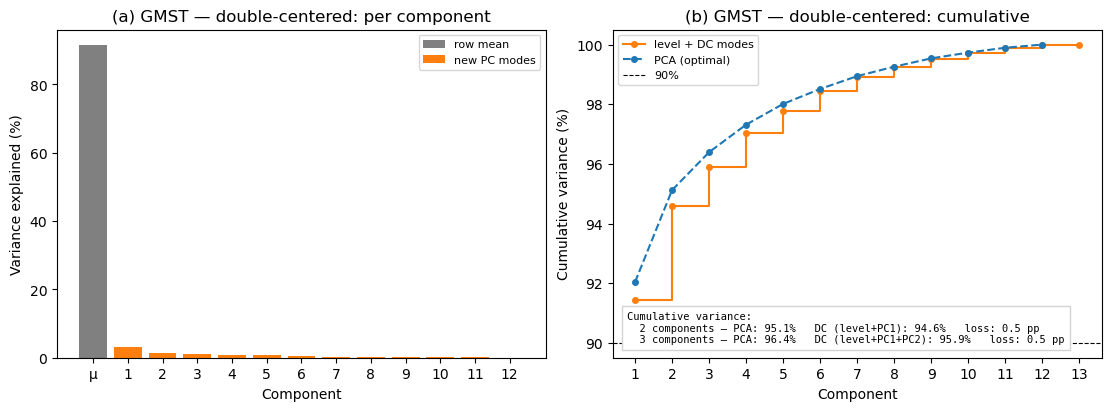

In [12]:
modes_dc = np.arange(1, 13)
fig, axs = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')

ax = axs[0]
ax.bar(0, var_mean_pct, color='gray', label='row mean')
ax.bar(modes_dc, var_dc_pct, color=colors[1], label='new PC modes')
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks([0] + list(modes_dc))
ax.set_xticklabels(['μ'] + [str(k) for k in modes_dc])
ax.set_xlabel('Component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('GMST — double-centered: per component')
ax.legend(fontsize=8)

ax = axs[1]
cumul = np.concatenate([[var_mean_pct], var_mean_pct + var_dc_cum_pct])
ax.step(range(13), cumul, where='post', color=colors[1], marker='o', ms=4, label='level + DC modes')
ax.plot(np.arange(0, 12), np.cumsum(var_gmt), color=colors[0], ls='--', marker='o', ms=4,
        label='PCA (optimal)')
ax.axhline(90, color='k', lw=0.8, ls='--', label='90%')
ax.set_xticks(range(13))
ax.set_xticklabels([str(k) for k in range(1, 14)])
ax.set_xlabel('Component')
ax.set_ylabel('Cumulative variance (%)')
ax.set_title('GMST — double-centered: cumulative')
ax.legend(fontsize=8)

pca_2  = float(np.cumsum(var_gmt)[1])
pca_3  = float(np.cumsum(var_gmt)[2])
dc_2   = var_mean_pct + var_dc_pct[0]          # mean + DC-PC1
dc_3   = var_mean_pct + var_dc_pct[0] + var_dc_pct[1]  # mean + DC-PC1 + DC-PC2
txt = ('Cumulative variance:\n'
       f'  2 components — PCA: {pca_2:.1f}%   DC (level+PC1): {dc_2:.1f}%   loss: {pca_2-dc_2:.1f} pp\n'
       f'  3 components — PCA: {pca_3:.1f}%   DC (level+PC1+PC2): {dc_3:.1f}%   loss: {pca_3-dc_3:.1f} pp')
ax.text(0.03, 0.04, txt, transform=ax.transAxes, fontsize=7.5, va='bottom',
        family='monospace', bbox=dict(facecolor='white', edgecolor='lightgray', pad=4))

label_fig(axs, 'variance_explained_dc')
fig.savefig(FIGURES_DIR / 'variance_explained_dc.pdf', bbox_inches='tight', metadata={'CreationDate': None})
plt.show()

## Shared DC diagnostics for `simplified_pred.pdf` and `corr_dec_n34_by_month.pdf`

These intermediates live inside the cut `eofs_pcs_dc` figure block in the oracle
but feed kept outputs: `beta_dec_n34` (regression of the DC residual on
standardized December Niño-3.4) feeds `corr_dec_n34_by_month.pdf`; `pc_level`,
`r_level_pc1`, and `r_dcpc1_pc2` feed `simplified_pred.pdf`.

In [13]:
# Regression of A_gmt_dc on standardised Dec Niño-3.4 (unit-variance predictor)
# β_m = cov(dec_n34_z, A_gmt_dc[:, m])  [var(dec_n34_z)=1 so slope = cov]
dec_n34_z = A_n34[:, DEC_COL]
dec_n34_z = (dec_n34_z - dec_n34_z.mean()) / dec_n34_z.std(ddof=1)
beta_dec_n34 = dec_n34_z @ A_gmt_dc / (N_years - 1)   # (12,) °C per std dev

# Level PC (unit-variance segment-mean series) and its correlations with the
# original PC1 / PC2.
pc_level = gmt_seg_mean / gmt_seg_mean.std(ddof=1)   # unit-variance level time series
r_level_pc1  = float(np.corrcoef(pc_level,      PC_gmt[0])[0, 1])
r_dcpc1_pc2  = float(np.corrcoef(PC_gmt_dc[0],  PC_gmt[1])[0, 1])

## Figure — `simplified_pred.pdf`: N34 PCs + Dec Niño-3.4 | GMST PCs (DC vs original)

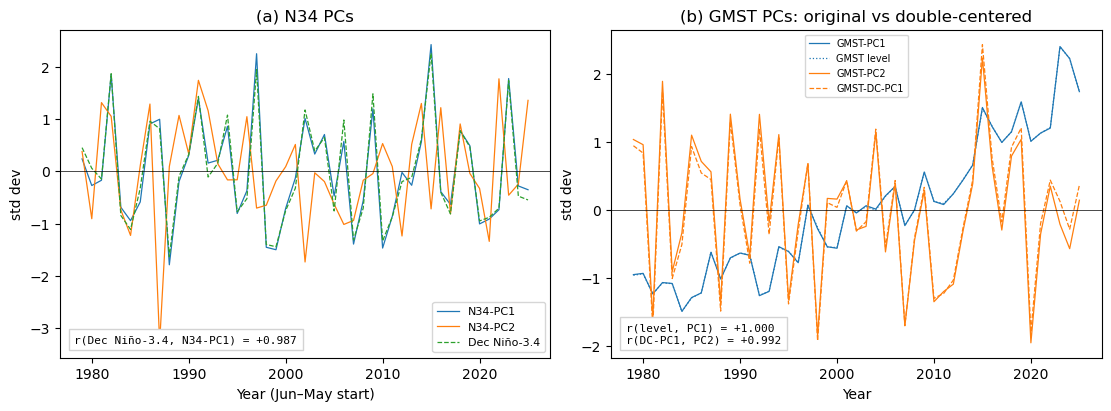

In [14]:
dec_n34_std  = A_n34[:, 6] / A_n34[:, 6].std(ddof=1)
r_dec_n34_pc1 = float(np.corrcoef(dec_n34_std, PC_n34[0])[0, 1])

fig, axs = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')

ax = axs[0]
for k, c in enumerate(colors[:2]):
    ax.plot(years, PC_n34[k], color=c, label=f'N34-PC{k+1}', lw=0.9)
ax.plot(years, dec_n34_std, color=colors[2], lw=0.9, ls='--', label='Dec Niño-3.4')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year (Jun–May start)')
ax.set_ylabel('std dev')
ax.set_title('N34 PCs')
ax.legend(fontsize=8)
ax.text(0.03, 0.04, f'r(Dec Niño-3.4, N34-PC1) = {r_dec_n34_pc1:+.3f}',
        transform=ax.transAxes, fontsize=8, va='bottom', family='monospace',
        bbox=dict(facecolor='white', edgecolor='lightgray', pad=4))

ax = axs[1]
ax.plot(years, PC_gmt[0],    color=colors[0], ls='-',  lw=0.9, label='GMST-PC1')
ax.plot(years, pc_level,      color=colors[0], ls=':',  lw=0.9, label='GMST level')
ax.plot(years, PC_gmt[1],    color=colors[1], ls='-',  lw=0.9, label='GMST-PC2')
ax.plot(years, PC_gmt_dc[0], color=colors[1], ls='--', lw=0.9, label='GMST-DC-PC1')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('std dev')
ax.set_title('GMST PCs: original vs double-centered')
ax.legend(fontsize=7)
ax.text(0.03, 0.04,
        f'r(level, PC1) = {r_level_pc1:+.3f}\nr(DC-PC1, PC2) = {r_dcpc1_pc2:+.3f}',
        transform=ax.transAxes, fontsize=8, va='bottom', family='monospace',
        bbox=dict(facecolor='white', edgecolor='lightgray', pad=4))

label_fig(axs, 'simplified_pred')
fig.savefig(FIGURES_DIR / 'simplified_pred.pdf', bbox_inches='tight', metadata={'CreationDate': None})
plt.show()

## RONI index and Figure — `corr_dec_n34_by_month.pdf`

Loads the NOAA CPC relative Niño-3.4 (RONI) index from the archive and compares
the by-month correlation of the DC GMST residual with December Niño-3.4 vs
December relative Niño-3.4.


December index variances (1979–2025, N=47):
  Dec Niño-3.4 variance: 1.4069  (std=1.1861)
  Dec RONI variance:     1.5319  (std=1.2377)
  Ratio (RONI/N34):      1.0889


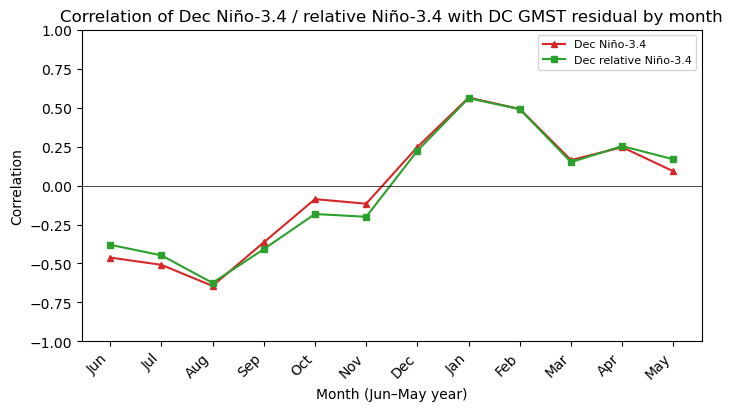

In [15]:
# ── Load RONI data (used here for correlation and later for OLS/response) ─
# data/Rnino34.ascii.txt: YR MTH ANOM, monthly from Dec 1949.
_roni_raw = np.loadtxt(DATA_DIR / 'Rnino34.ascii.txt',
                       skiprows=1, usecols=(0, 1, 2))
_roni_years  = _roni_raw[:, 0].astype(int)
_roni_months = _roni_raw[:, 1].astype(int)
_roni_anom   = _roni_raw[:, 2]
_roni_dec_mask  = _roni_months == 12
_roni_dec_years = _roni_years[_roni_dec_mask]
_roni_dec_vals  = _roni_anom[_roni_dec_mask]

# All N_years Dec RONI values (1979..2025) — for correlation with A_gmt_dc
dec_roni_all = np.array([_roni_dec_vals[_roni_dec_years == y][0]
                         for y in years])                     # (N_years,)
# (N_years-1)-value subset (1980..2025) — for OLS matching t+1 = 1..N_years-1
dec_roni = dec_roni_all[1:]                                   # (N_years-1,)

dec_n34_all = A_n34[:, DEC_COL]   # full-period anomaly, all N_years years 1979–2025
print(f"\nDecember index variances (1979–2025, N={N_years}):")
print(f"  Dec Niño-3.4 variance: {np.var(dec_n34_all, ddof=1):.4f}  (std={np.std(dec_n34_all, ddof=1):.4f})")
print(f"  Dec RONI variance:     {np.var(dec_roni_all, ddof=1):.4f}  (std={np.std(dec_roni_all, ddof=1):.4f})")
print(f"  Ratio (RONI/N34):      {np.var(dec_roni_all, ddof=1)/np.var(dec_n34_all, ddof=1):.4f}")

# ── Correlation of A_gmt_dc with Dec Niño-3.4 / RONI by month ─────────────
corr_dec_n34 = beta_dec_n34 / A_gmt_dc.std(axis=0, ddof=1)   # r = β / σ_y

# RONI: OLS slope of each month of A_gmt_dc on standardised Dec RONI (all N_years yrs)
_dec_roni_z   = (dec_roni_all - dec_roni_all.mean()) / dec_roni_all.std(ddof=1)
_beta_dec_roni = _dec_roni_z @ A_gmt_dc / (N_years - 1)       # (12,) °C per std dev
corr_dec_roni  = _beta_dec_roni / A_gmt_dc.std(axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(7, 4), layout='constrained')
ax.plot(x_eof, corr_dec_n34,  color=colors[3], marker='^', ms=4, lw=1.5,
        label='Dec Niño-3.4')
ax.plot(x_eof, corr_dec_roni, color=colors[2], marker='s', ms=4, lw=1.5,
        label='Dec relative Niño-3.4')
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x_eof); ax.set_xticklabels(m_str_jm, rotation=45, ha='right')
ax.set_xlabel('Month (Jun–May year)')
ax.set_ylabel('Correlation')
ax.set_ylim(-1, 1)
ax.set_title('Correlation of Dec Niño-3.4 / relative Niño-3.4 with DC GMST residual by month')
ax.legend(fontsize=8)
fig.savefig(FIGURES_DIR / 'corr_dec_n34_by_month.pdf', bbox_inches='tight', metadata={'CreationDate': None})
plt.show()

## Simplified-model regression (level + Dec Niño-3.4 → level, DC-PC1, DC-PC2)

In [16]:
# ── Regression with new predictand ───────────────────────────────────────
# Y_dc: (N_years-1, 3) — segment mean, new PC1, new PC2 at time t+1
Y_dc  = np.column_stack([gmt_seg_mean[1:], PC_gmt_dc[0, 1:], PC_gmt_dc[1, 1:]])
X_dc  = np.column_stack([gmt_seg_mean[:-1], A_n34[1:, DEC_COL]])
X1_dc = np.column_stack([np.ones(X_dc.shape[0]), X_dc])

B_dc, *_ = np.linalg.lstsq(X1_dc, Y_dc, rcond=None)
Yhat_dc   = X1_dc @ B_dc    # (N_years-1, 3)

pred_names_dc = ['intercept', 'GMST mean(t)', 'Dec N34(t+1)']
tgt_names_dc  = ['→ GMT mean(t+1)', '→ new PC1(t+1)', '→ new PC2(t+1)']
print(f"\nSimplified model coefficients:")
print(f"{'Predictor':>16}   " + "   ".join(f"{n:>16}" for n in tgt_names_dc))
for name, row in zip(pred_names_dc, B_dc):
    print(f"{name:>16}   " + "   ".join(f"{v:>16.4f}" for v in row))

# Reconstruct: A_hat[t,:] = fitted_mean[t]*ones + EOF_dc[:,:2] @ fitted_PCs[t]
ones12 = np.ones(12)
gmt_fit_dc = (Yhat_dc[:, 0:1] * ones12[None, :]
              + (EOF_gmt_dc[:, :2] @ Yhat_dc[:, 1:].T).T)
gmt_fit_dc_flat = gmt_fit_dc.flatten()

rmse_dc, r2_dc = rmse_r2(gmt_true, gmt_fit_dc_flat)
print(f"\nSimplified model fit:   RMSE={rmse_dc:.3f}  R²={r2_dc:.3f}")
print(f"2-PC model fit:         RMSE={rmse_r1:.3f}  R²={r2_r1:.3f}")


Simplified model coefficients:
       Predictor    → GMT mean(t+1)     → new PC1(t+1)     → new PC2(t+1)
       intercept             0.0178            -0.0133            -0.0094
    GMST mean(t)             0.9814             0.0974             0.9706
    Dec N34(t+1)             0.0664             0.5269             0.2276

Simplified model fit:   RMSE=0.116  R²=0.855
2-PC model fit:         RMSE=0.114  R²=0.859


## Figure — `fit_idea2.pdf`: Simplified model fit vs original

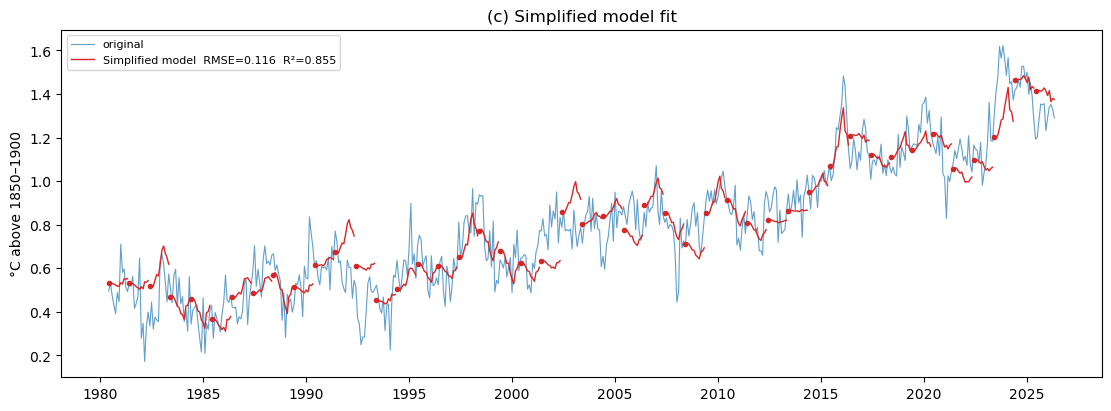

In [17]:
fig, ax = plt.subplots(figsize=(11, 4), layout='constrained')
ax.plot(time_fit, gmt_true + _shift_fit, lw=0.8, alpha=0.7, label='original', color=colors[0])
for i in range(N_years - 1):
    seg_t = time_fit[i * 12:(i + 1) * 12]
    seg_v = (gmt_fit_dc_flat + _shift_fit)[i * 12:(i + 1) * 12]
    ax.plot(seg_t, seg_v, lw=1.0, color=colors[3],
            label=f'Simplified model  RMSE={rmse_dc:.3f}  R²={r2_dc:.3f}' if i == 0 else None)
    ax.plot(seg_t[0:1], seg_v[0:1], 'o', ms=3, color=colors[3])
ax.set_ylabel('°C above 1850–1900')
ax.set_title('Simplified model fit')
ax.legend(fontsize=8)
label_fig([ax], 'fit_idea2')
fig.savefig(FIGURES_DIR / 'fit_idea2.pdf', bbox_inches='tight', metadata={'CreationDate': None})

plt.show()

## Figure — `fit_all.pdf`: original + 4-PC + 2-PC model fits

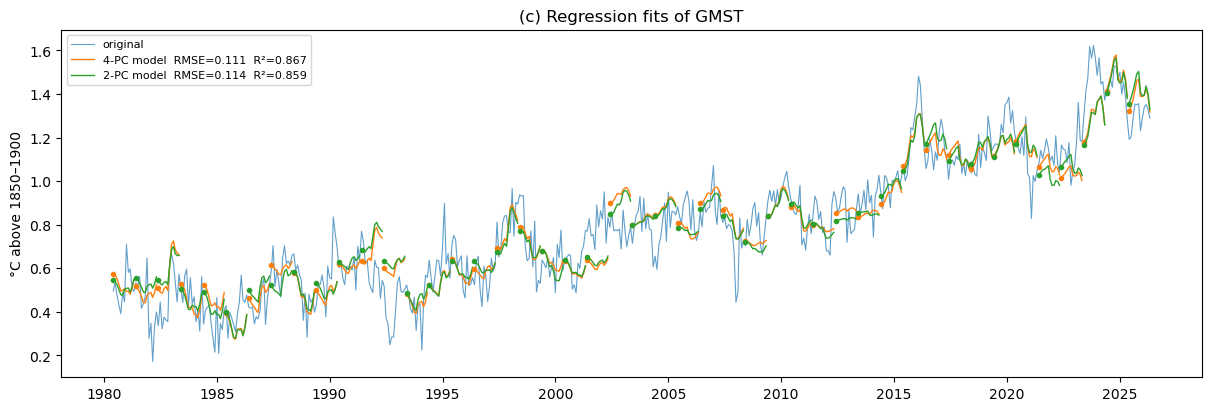

In [18]:
_fit_all    = gmt_fit         + _shift_fit
_fit_all_r1 = gmt_fit_r1      + _shift_fit
_fit_all_dc = gmt_fit_dc_flat + _shift_fit

fig, ax = plt.subplots(figsize=(12, 4), layout='constrained')
ax.plot(time_fit, gmt_true + _shift_fit, lw=0.8, alpha=0.7, label='original', color=colors[0])
for i in range(N_years - 1):
    seg_t = time_fit[i * 12:(i + 1) * 12]
    ax.plot(seg_t, _fit_all[i * 12:(i + 1) * 12], lw=1.0, color=colors[1],
            label=f'4-PC model  RMSE={rmse_fit:.3f}  R²={r2_fit:.3f}' if i == 0 else None)
    ax.plot(seg_t[0:1], _fit_all[i * 12:i * 12 + 1], 'o', ms=3, color=colors[1])
    ax.plot(seg_t, _fit_all_r1[i * 12:(i + 1) * 12], lw=1.0, color=colors[2],
            label=f'2-PC model  RMSE={rmse_r1:.3f}  R²={r2_r1:.3f}' if i == 0 else None)
    ax.plot(seg_t[0:1], _fit_all_r1[i * 12:i * 12 + 1], 'o', ms=3, color=colors[2])
ax.set_ylabel('°C above 1850–1900')
ax.set_title('Regression fits of GMST')
ax.legend(fontsize=8, loc='upper left')
label_fig([ax], 'fit_all')
fig.savefig(FIGURES_DIR / 'fit_all.pdf', bbox_inches='tight', metadata={'CreationDate': None})
plt.show()

## Tables — OLS regression tables

`make_reg_table` renders a statsmodels `summary_col` block to a LaTeX `tabular`.
Four tables are written: `regression_table_full.tex` (4-PC model),
`regression_table_r1.tex` (2-PC model), `regression_table_dc2.tex` (Simplified
model), and `regression_table_dc2_roni.tex` (RONI variant of the Simplified
model). The RONI OLS objects are also reused by the ENSO-response section below.

In [19]:
# =============================================================================
# OLS regression via statsmodels: one model per predictand component.
# Using a named DataFrame so variable labels appear in summary tables.
# =============================================================================
import re

def make_reg_table(models, names):
    """Extract LaTeX tabular block from statsmodels OLS objects; unescape \\$ → $."""
    tbl = summary_col(models, model_names=names, stars=True,
                      float_format='%.3f',
                      info_dict={'$N$': lambda m: f'{int(m.nobs)}'})
    full_tex = tbl.as_latex()
    tabular = re.search(r'(\\begin\{tabular\}.*?\\end\{tabular\})', full_tex, re.DOTALL).group(1)
    tabular = tabular.replace('\\$', '$')
    return (tabular + '\n\n'
            + r'{Standard errors in parentheses. * $p<.1$, ** $p<.05$, *** $p<.01$}')

# ── OLS fits: 4-PC model ─────────────────────────────────────────────────
X_full_df = pd.DataFrame(X1, columns=['const', 'GMST-PC1(t)', 'GMST-PC2(t)',
                                       'N34-PC1(t+1)', 'N34-PC2(t+1)'])
ols_full_pc1 = sm.OLS(PC_gmt[0, 1:], X_full_df).fit()
ols_full_pc2 = sm.OLS(PC_gmt[1, 1:], X_full_df).fit()
(TABLES_DIR / 'regression_table_full.tex').write_text(
    make_reg_table([ols_full_pc1, ols_full_pc2],
                   ['GMST-PC1$(t+1)$', 'GMST-PC2$(t+1)$']))
print("LaTeX table written: regression_table_full.tex")

# ── OLS fits: 2-PC model ─────────────────────────────────────────────────
X_r1_df = pd.DataFrame(X1_r1, columns=['const', 'GMST-PC1(t)', 'N34-PC1(t+1)'])
ols_r1_pc1 = sm.OLS(PC_gmt[0, 1:], X_r1_df).fit()
ols_r1_pc2 = sm.OLS(PC_gmt[1, 1:], X_r1_df).fit()
(TABLES_DIR / 'regression_table_r1.tex').write_text(
    make_reg_table([ols_r1_pc1, ols_r1_pc2],
                   ['GMST-PC1$(t+1)$', 'GMST-PC2$(t+1)$']))
print("LaTeX table written: regression_table_r1.tex")

# ── OLS fits: Simplified model ───────────────────────────────────────────
X_df = pd.DataFrame(X1_dc, columns=['const', 'GMST mean(t)', 'Dec N34(t+1)'])

ols_mean = sm.OLS(gmt_seg_mean[1:],  X_df).fit()
ols_pc1  = sm.OLS(PC_gmt_dc[0, 1:], X_df).fit()
ols_pc2  = sm.OLS(PC_gmt_dc[1, 1:], X_df).fit()   # kept for comparison

print("\nOLS: GMT mean(t+1)")
print(ols_mean.summary2().tables[1].to_string())
print("\nOLS: new PC1(t+1)")
print(ols_pc1.summary2().tables[1].to_string())
print("\nOLS: new PC2(t+1)")
print(ols_pc2.summary2().tables[1].to_string())

# ── OLS table: forecast model (new PC2 dropped) ──────────────────────────
_tab_dc2 = make_reg_table([ols_mean, ols_pc1],
                           ['GMST mean$(t+1)$', 'DC-PC1$(t+1)$'])
_tab_dc2 = _tab_dc2.replace('Dec N34(t+1)', r'Dec Ni\~{n}o-3.4$(t+1)$')
(TABLES_DIR / 'regression_table_dc2.tex').write_text(_tab_dc2)
print("LaTeX table written: regression_table_dc2.tex")

# ── OLS table: RONI version of forecast model ────────────────────────────
# Fit here so table is written alongside the other tables; RONI OLS also
# re-used later in the ENSO response section.
_X_roni_df = pd.DataFrame({'const': 1.0,
                           'GMST mean(t)': gmt_seg_mean[:-1],
                           'Dec rN34(t+1)': dec_roni},
                          columns=['const', 'GMST mean(t)', 'Dec rN34(t+1)'])
ols_mean_roni = sm.OLS(gmt_seg_mean[1:],  _X_roni_df).fit()
ols_pc1_roni  = sm.OLS(PC_gmt_dc[0, 1:], _X_roni_df).fit()
_tab_roni = make_reg_table([ols_mean_roni, ols_pc1_roni],
                            ['GMST mean$(t+1)$', 'DC-PC1$(t+1)$'])
_tab_roni = _tab_roni.replace('Dec rN34(t+1)', r'Dec rel.\ Ni\~{n}o-3.4$(t+1)$')
(TABLES_DIR / 'regression_table_dc2_roni.tex').write_text(_tab_roni)
print("LaTeX table written: regression_table_dc2_roni.tex")

LaTeX table written: regression_table_full.tex
LaTeX table written: regression_table_r1.tex

OLS: GMT mean(t+1)
                 Coef.  Std.Err.          t         P>|t|    [0.025    0.975]
const         0.017781  0.012562   1.415444  1.641406e-01 -0.007553  0.043116
GMST mean(t)  0.981360  0.044689  21.959609  5.401671e-25  0.891235  1.071484
Dec N34(t+1)  0.066394  0.010707   6.201233  1.863167e-07  0.044802  0.087986

OLS: new PC1(t+1)
                 Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
const        -0.013263  0.117781 -0.112608  0.910866 -0.250791  0.224265
GMST mean(t)  0.097376  0.418993  0.232405  0.817326 -0.747604  0.942356
Dec N34(t+1)  0.526878  0.100381  5.248776  0.000004  0.324440  0.729316

OLS: new PC2(t+1)
                 Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
const        -0.009381  0.140527 -0.066758  0.947084 -0.292781  0.274018
GMST mean(t)  0.970604  0.499909  1.941559  0.058761 -0.037560  1.978767
Dec N34(t+1)  0.227552  0.1

## Simplified model kept to level + DC-PC1, and the ENSO response

`gmt_fit_2c` (Simplified model reconstruction using only the level and DC-PC1
fitted components) feeds the forecast figure's y-limits and hindcast panels.
The ENSO-response betas (level and shape contributions per +1 °C December
Niño-3.4, for both Niño-3.4 and relative Niño-3.4) feed the forecast figure's
left panel.

In [20]:
# ── Performance: Simplified model keeping only level + new PC1 ───────────
# Reconstruct trajectory using only the two fitted components (drop new PC2).
Yhat_2comp = np.column_stack([ols_mean.fittedvalues, ols_pc1.fittedvalues])
gmt_fit_2c = (Yhat_2comp[:, 0:1] * ones12[None, :]
              + (EOF_gmt_dc[:, 0:1] @ Yhat_2comp[:, 1:2].T).T)
rmse_2c, r2_2c = rmse_r2(gmt_true, gmt_fit_2c.flatten())
print(f"\nSimplified model (level + new PC1 only):  RMSE={rmse_2c:.3f}  R²={r2_2c:.3f}")
print(f"Simplified model (level + PC1 + PC2):     RMSE={rmse_dc:.3f}  R²={r2_dc:.3f}")

# ── ENSO response of the simplified model ────────────────────────────────
# Jun–May GMST response to 1 °C of Dec Niño-3.4 anomaly, split into its two
# additive contributions from the two OLS equations:
#   level contribution:  beta_mean_n34  × ones(12)
#   shape contribution:  beta_pc1_n34   × EOF_gmt_dc[:, 0]
# Coefficients are at index 2 of params ([intercept, GMT_mean(t), Dec_N34(t+1)]).
beta_mean_n34 = float(ols_mean.params.iloc[2])
beta_pc1_n34  = float(ols_pc1.params.iloc[2])
enso_level    = beta_mean_n34 * np.ones(12)
enso_shape    = beta_pc1_n34  * EOF_gmt_dc[:, 0]
enso_total    = enso_level + enso_shape
# Jun=0, Jul=1, Aug=2, ..., Feb=8 in Jun–May order
jja_avg_n34 = enso_total[:3].mean()
feb_n34     = enso_total[8]
print(f"\nN34 total (left panel, ENSO response per +1 °C Dec Niño-3.4):")
print(f"  Jun–Aug average: {jja_avg_n34:+.4f} °C")
print(f"  February value:  {feb_n34:+.4f} °C")

# ── RONI response: parallel OLS results computed earlier (table section) ─
# ols_mean_roni, ols_pc1_roni, dec_roni already defined.
beta_mean_roni = float(ols_mean_roni.params['Dec rN34(t+1)'])
beta_pc1_roni  = float(ols_pc1_roni.params['Dec rN34(t+1)'])
roni_level     = beta_mean_roni * np.ones(12)
roni_shape     = beta_pc1_roni  * EOF_gmt_dc[:, 0]
roni_total     = roni_level + roni_shape
print(f"\nRONI response: beta_mean={beta_mean_roni:+.3f}  beta_pc1={beta_pc1_roni:+.3f}")


Simplified model (level + new PC1 only):  RMSE=0.116  R²=0.853
Simplified model (level + PC1 + PC2):     RMSE=0.116  R²=0.855

N34 total (left panel, ENSO response per +1 °C Dec Niño-3.4):
  Jun–Aug average: +0.0307 °C
  February value:  +0.1077 °C

RONI response: beta_mean=+0.061  beta_pc1=+0.523


## Conditional forecast (Jun 2026 – May 2027) with 95% prediction interval

In [21]:
# =============================================================================
# Conditional forecast in preindustrial units
#
# Model: GMT mean(t) + Dec N34(t+1)  →  GMT mean(t+1) and new PC1(t+1)
# Reconstruction:
#   gmt_june_may[t+1, :] ≈ gmt_col_mean + gmt_mean_fcast * ones + EOF_dc[:,0] * gmt_pc1_fcast
# Convert to preindustrial:  add GMT_PREIND_SHIFT
# =============================================================================
# The Jun 2025 – May 2026 GMT segment is now complete (index N_years-1 = 46).
gmt_seg_mean_recent = gmt_seg_mean[N_years - 1]
gmt_recent_raw      = gmt_seg_mean_recent + float(np.mean(gmt_col_mean))
print(f"Recent GMT (Jun 2025–May 2026): "
      f"{gmt_recent_raw:+.3f} degC (NOAA base) → "
      f"predictor = {gmt_seg_mean_recent:+.3f} degC")

dec_n34_forecast = 3.3   # NMME multimodel mean Dec 2026 Niño-3.4 (°C, 1991–2020 base; Jun 2026 start, 6 of 7 models)
dec_n34_forecast_model = dec_n34_forecast - N34_DEC_1991_2020_SHIFT  # convert to full-period anomaly for model

x_fcast = np.array([1.0, gmt_seg_mean_recent, dec_n34_forecast_model])
gmt_mean_fcast = ols_mean.params @ x_fcast
gmt_pc1_fcast  = ols_pc1.params  @ x_fcast

gmt_traj_fcast  = gmt_col_mean + gmt_mean_fcast * ones12 + EOF_gmt_dc[:, 0] * gmt_pc1_fcast
gmt_traj_preind = gmt_traj_fcast + GMT_PREIND_SHIFT

# --- 95% prediction interval ---
# Trajectory residual: resid[t,m] = ols_mean.resid[t] + EOF_dc[m,0] * ols_pc1.resid[t]
# Prediction variance at month m (new obs, not just fitted value):
#   Var[m] = (1 + h) * (sigma11 + 2*EOF[m]*sigma12 + EOF[m]^2 * sigma22)
# where sigma11, sigma22 are MSEs; sigma12 is cross-residual covariance; h is leverage.
from scipy.stats import t as t_dist
n_ols  = int(ols_mean.nobs)          # 46
df_ols = n_ols - 3                   # intercept + 2 predictors
sigma11 = ols_mean.scale             # MSE, mean model
sigma22 = ols_pc1.scale              # MSE, PC1 model
sigma12 = float(np.dot(ols_mean.resid, ols_pc1.resid)) / df_ols  # cross-MSE

XtXinv     = np.linalg.inv(X1_dc.T @ X1_dc)
lev_fcast  = float(x_fcast @ XtXinv @ x_fcast)     # leverage for new point

e_var = (1 + lev_fcast) * (
    sigma11
    + 2 * EOF_gmt_dc[:, 0] * sigma12
    + EOF_gmt_dc[:, 0]**2 * sigma22
)   # (12,) prediction variance in NOAA anomaly units
t_crit  = t_dist.ppf(0.975, df_ols)
pi_half = t_crit * np.sqrt(np.maximum(e_var, 0))   # (12,)

pi_lo = gmt_traj_preind - pi_half
pi_hi = gmt_traj_preind + pi_half

print(f"\nConditional forecast (Jun 2026 – May 2027):")
print(f"  GMT mean (Jun 2025–May 2026): {gmt_recent_raw:+.3f} degC (NOAA base)")
print(f"  GMT mean (Jun 2025–May 2026): {gmt_recent_raw + GMT_PREIND_SHIFT:+.3f} °C above 1850–1900")
print(f"  Assumed Dec 2026 Niño-3.4:   {dec_n34_forecast:+.1f} °C (1991–2020 base)"
      f"  →  {dec_n34_forecast_model:+.3f} °C (full-period base)")
print(f"  Predicted Jun 2026–May 2027 GMT (preindustrial units):")
for m, lo, v, hi in zip(m_str_jm, pi_lo, gmt_traj_preind, pi_hi):
    print(f"    {m}: {v:+.3f} °C  (95% PI: {lo:+.3f} to {hi:+.3f})")

Recent GMT (Jun 2025–May 2026): +0.514 degC (NOAA base) → predictor = +0.509 degC

Conditional forecast (Jun 2026 – May 2027):
  GMT mean (Jun 2025–May 2026): +0.514 degC (NOAA base)
  GMT mean (Jun 2025–May 2026): +1.298 °C above 1850–1900
  Assumed Dec 2026 Niño-3.4:   +3.3 °C (1991–2020 base)  →  +3.323 °C (full-period base)
  Predicted Jun 2026–May 2027 GMT (preindustrial units):
    Jun: +1.406 °C  (95% PI: +1.192 to +1.620)
    Jul: +1.395 °C  (95% PI: +1.176 to +1.614)
    Aug: +1.403 °C  (95% PI: +1.188 to +1.618)
    Sep: +1.447 °C  (95% PI: +1.247 to +1.647)
    Oct: +1.482 °C  (95% PI: +1.288 to +1.676)
    Nov: +1.466 °C  (95% PI: +1.270 to +1.662)
    Dec: +1.553 °C  (95% PI: +1.350 to +1.757)
    Jan: +1.659 °C  (95% PI: +1.407 to +1.910)
    Feb: +1.676 °C  (95% PI: +1.416 to +1.936)
    Mar: +1.649 °C  (95% PI: +1.405 to +1.894)
    Apr: +1.613 °C  (95% PI: +1.390 to +1.837)
    May: +1.570 °C  (95% PI: +1.365 to +1.776)


## NMME GMST forecast trajectory and shared y-limits

The archive `GMSTa` is the per-model ensemble mean over members, so the original
pickle's `.sel(S=June).mean('M')` step is unnecessary (all initializations are
June). The ±2σ shading uses the 1991–2024 historical error standard deviation.
The shared y-limit block sets the forecast figure's axis (derived from the six
hindcast years plus the forecast and NMME trajectories).

In [22]:
# ── NMME GMST Jun 2026 multimodel mean forecast ──────────────────────────────
_ds_nmme_fcast = xr.open_dataset(
    DATA_DIR / 'nmme_n34a_GMSTa_199106-202606.nc'
).rename({'init_time': 'S', 'lead': 'L'})
_jm_m        = _ds_nmme_fcast.GMSTa                                   # (model, S, L) ensemble mean
_jm_a        = _jm_m - _jm_m.sel(S=slice('1991', '2020')).mean('S')
_jm_mm       = _jm_a.mean('model')                                   # (S_june, L)
_nmme_jun26_traj = (
    _jm_mm.sel(S=_jm_mm.S.dt.year == 2026).squeeze().values
    + GMT_PREIND_SHIFT
)                                                                     # (12,) preindustrial

# ── NMME GMT ±2σ shading: historical error std 1991–2024 ─────────────────────
_NMME_COMMON = np.arange(1991, 2025)
_nmme_sigma_mask = _jm_mm.S.dt.year.isin(_NMME_COMMON)
_nmme_hist    = _jm_mm.sel(S=_nmme_sigma_mask).values              # (34, 12) 1991–2020 anom
_obs_idx      = _NMME_COMMON - int(years[0])                        # 1991→12 … 2024→45
_obs_hist     = gmt_june_may[_obs_idx, :]                           # (34, 12) NOAA 1991–2020 anom
_sigma_nmme_gmt = np.nanstd(_nmme_hist - _obs_hist, axis=0)        # (12,)

# ── Shared ylim for forecast left panel + hindcast panels ────────────────────
target_years = [2007, 2009, 2010, 2015, 2020, 2023]   # left col: cool; right col: warm; rows ascending by year
year_start = int(years[0])   # 1979
lev_insample = np.array([float(X1_dc[i] @ XtXinv @ X1_dc[i]) for i in range(len(X1_dc))])

_nmme_lo = _nmme_jun26_traj - 2 * _sigma_nmme_gmt
_nmme_hi = _nmme_jun26_traj + 2 * _sigma_nmme_gmt
_y_all = (list(pi_lo) + list(pi_hi) + list(gmt_traj_preind)
          + list(_nmme_jun26_traj[np.isfinite(_nmme_jun26_traj)])
          + list(_nmme_lo[np.isfinite(_nmme_lo)])
          + list(_nmme_hi[np.isfinite(_nmme_hi)])
          + [gmt_recent_raw + GMT_PREIND_SHIFT])
for _yr in target_years:
    _s = _yr - year_start
    _i = _s - 1
    _fit = gmt_fit_2c[_i, :] + gmt_col_mean + GMT_PREIND_SHIFT
    _obs = gmt_june_may[_s, :] + GMT_PREIND_SHIFT
    _e_var_i = (1 + lev_insample[_i]) * (
        sigma11 + 2 * EOF_gmt_dc[:, 0] * sigma12 + EOF_gmt_dc[:, 0]**2 * sigma22
    )
    _pi_half_i = t_crit * np.sqrt(np.maximum(_e_var_i, 0))
    _y_all += list(_fit - _pi_half_i) + list(_fit + _pi_half_i) + list(_fit) + list(_obs)
    _y_all.append(float(gmt_june_may[_s - 1, :].mean()) + GMT_PREIND_SHIFT)
_pad = 0.05
shared_ylim = (np.floor((min(_y_all) - _pad) * 10) / 10,
               np.ceil((max(_y_all) + _pad) * 10) / 10)

## Figure — `forecast.pdf`: ENSO response (left) and conditional forecast (right)

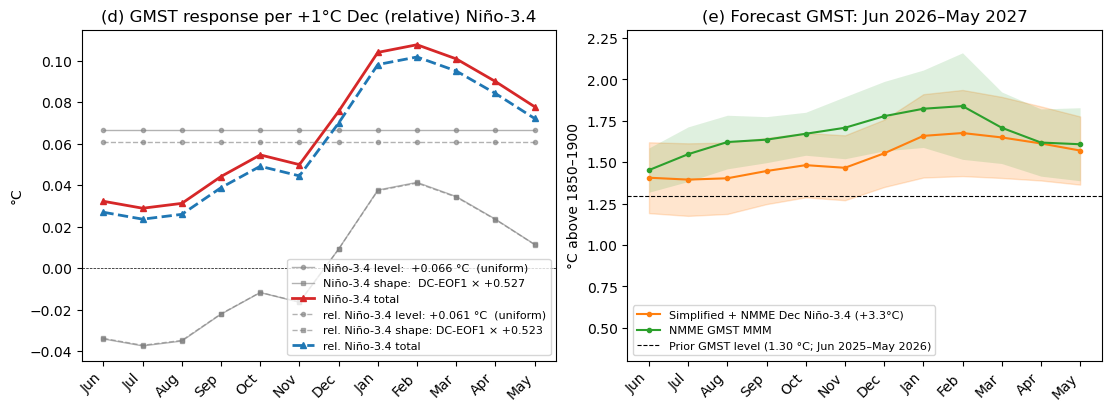

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')

# ── Left panel: ENSO response ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_eof, enso_level, color='gray', lw=1.0, marker='o', ms=3, alpha=0.6,
        label=f'Niño-3.4 level:  {beta_mean_n34:+.3f} °C  (uniform)')
ax.plot(x_eof, enso_shape, color='gray', lw=1.0, marker='s', ms=3, alpha=0.6,
        label=f'Niño-3.4 shape:  DC-EOF1 × {beta_pc1_n34:+.3f}')
ax.plot(x_eof, enso_total, color=colors[3], lw=2.0, marker='^', ms=5,
        label='Niño-3.4 total')
ax.plot(x_eof, roni_level, color='gray', lw=1.0, marker='o', ms=3, alpha=0.6, ls='--',
        label=f'rel. Niño-3.4 level: {beta_mean_roni:+.3f} °C  (uniform)')
ax.plot(x_eof, roni_shape, color='gray', lw=1.0, marker='s', ms=3, alpha=0.6, ls='--',
        label=f'rel. Niño-3.4 shape: DC-EOF1 × {beta_pc1_roni:+.3f}')
ax.plot(x_eof, roni_total, color=colors[0], lw=2.0, marker='^', ms=5, ls='--',
        label='rel. Niño-3.4 total')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xticks(x_eof)
ax.set_xticklabels(m_str_jm, rotation=45, ha='right')
ax.set_ylabel('°C')
ax.set_title('GMST response per +1°C Dec (relative) Niño-3.4')
ax.legend(fontsize=8)

# ── Right panel: conditional forecast ────────────────────────────────────────
ax = axes[1]
_x12 = np.arange(12)
ax.fill_between(_x12, pi_lo, pi_hi, alpha=0.2, color=colors[1])
ax.plot(_x12, gmt_traj_preind, marker='o', ms=3, lw=1.5, color=colors[1],
        label=f'Simplified + NMME Dec Niño-3.4 ({dec_n34_forecast:+.1f}°C)')
_valid = np.isfinite(_nmme_jun26_traj)
ax.fill_between(_x12[_valid], _nmme_lo[_valid], _nmme_hi[_valid],
                color=colors[2], alpha=0.15, lw=0)
ax.plot(_x12[_valid], _nmme_jun26_traj[_valid],
        marker='o', ms=3, lw=1.5, color=colors[2], label='NMME GMST MMM')
ax.axhline(gmt_recent_raw + GMT_PREIND_SHIFT, color='k', lw=0.8, ls='--',
           label=f'Prior GMST level ({gmt_recent_raw + GMT_PREIND_SHIFT:.2f} °C; Jun 2025–May 2026)')
ax.set_xticks(_x12)
ax.set_xticklabels(m_str_jm, rotation=45, ha='right')
ax.set_ylabel('°C above 1850–1900')
ax.set_title('Forecast GMST: Jun 2026–May 2027')
ax.set_ylim(shared_ylim)
ax.legend(fontsize=8)

label_fig(axes, 'forecast')
fig.savefig(FIGURES_DIR / 'forecast.pdf', bbox_inches='tight', metadata={'CreationDate': None})
plt.show()